# Round 3 volatility smile

This notebook builds a volatility smile for the `VELVETFRUIT_EXTRACT` vouchers using the round 3 price files.

Workflow:
- collect option mids and underlying mids from the CSVs
- back out Black-Scholes implied vol for every option observation
- convert strike to normalised log-moneyness `log(K / S) / sqrt(T)`
- fit a quadratic smile `IV = a*m^2 + b*m + c`

Note: the current round-3 bot uses `days_left = 8 - round_number`, so for round 3 this notebook uses `T = 5 / 365` years.

In [5]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("/Users/aditya/Documents/university_resource_files/prosperity_4/prosperity-4/data/ROUND_3")
PRICE_FILES = sorted(DATA_DIR.glob("prices_round_3_day_*.csv"))

UNDERLYING = "VELVETFRUIT_EXTRACT"
OPTION_STRIKES = {
    "VEV_4000": 4000,
    "VEV_4500": 4500,
    "VEV_5000": 5000,
    "VEV_5100": 5100,
    "VEV_5200": 5200,
    "VEV_5300": 5300,
    "VEV_5400": 5400,
    "VEV_5500": 5500,
    "VEV_6000": 6000,
    "VEV_6500": 6500,
}

# Matches src/submissions/round3.py for ROUND_NUMBER = 3.
DAYS_LEFT = 5
T = DAYS_LEFT / 365.0


def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_call_price(S: float, K: float, T: float, sigma: float) -> float:
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)

    vol_sqrt_t = sigma * math.sqrt(T)
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t
    return S * norm_cdf(d1) - K * norm_cdf(d2)


def implied_vol_call_bisection(price: float, S: float, K: float, T: float) -> float:
    intrinsic = max(S - K, 0.0)

    if price < intrinsic - 1e-9 or price > S + 1e-9:
        return float("nan")

    if price <= intrinsic + 1e-9:
        return 0.0

    lo, hi = 1e-6, 5.0
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        mid_price = bs_call_price(S, K, T, mid)

        if abs(mid_price - price) < 1e-8:
            return mid

        if mid_price > price:
            hi = mid
        else:
            lo = mid

    return 0.5 * (lo + hi)


def load_round3_option_observations() -> pd.DataFrame:
    parts = []

    for price_file in PRICE_FILES:
        df = pd.read_csv(price_file, sep=";")

        underlying = (
            df.loc[df["product"] == UNDERLYING, ["day", "timestamp", "mid_price"]]
            .rename(columns={"mid_price": "S"})
        )

        options = df.loc[df["product"].isin(OPTION_STRIKES), ["day", "timestamp", "product", "mid_price"]].copy()
        options["K"] = options["product"].map(OPTION_STRIKES)
        options = options.rename(columns={"mid_price": "C"})

        merged = options.merge(underlying, on=["day", "timestamp"], how="inner")
        merged["T"] = T
        merged["intrinsic_value"] = (merged["S"] - merged["K"]).clip(lower=0)
        merged["extrinsic_value"] = merged["C"] - merged["intrinsic_value"]
        merged["implied_vol"] = merged.apply(
            lambda row: implied_vol_call_bisection(row["C"], row["S"], row["K"], row["T"]),
            axis=1,
        )
        merged["moneyness"] = merged.apply(
            lambda row: math.log(row["K"] / row["S"]) / math.sqrt(row["T"]),
            axis=1,
        )
        parts.append(merged)

    observations = pd.concat(parts, ignore_index=True)
    observations = observations.replace([np.inf, -np.inf], np.nan)
    observations = observations.dropna(subset=["implied_vol", "moneyness"])
    return observations.sort_values(["day", "timestamp", "K"]).reset_index(drop=True)


observations = load_round3_option_observations()
observations.head()

,day,timestamp,product,C,K,S,T,intrinsic_value,extrinsic_value,implied_vol,moneyness
0,0,0,VEV_4000,1250.0,4000,5250.0,0.013699,1250.0,0.0,0.000000,-2.323403
1,0,0,VEV_4500,750.0,4500,5250.0,0.013699,750.0,0.0,0.000000,-1.317064
2,0,0,VEV_5000,257.0,5000,5250.0,0.013699,250.0,7.0,0.302730,-0.416863
3,0,0,VEV_5100,171.5,5100,5250.0,0.013699,150.0,21.5,0.303645,-0.247670
4,0,0,VEV_5200,101.5,5200,5250.0,0.013699,50.0,51.5,0.302603,-0.081761


raw all-quoted coeffs : [0.12676126, -0.00273748, 0.26770554]
bot-ready coeffs      : [0.02721888, 0.00285325, 0.27239067]

SMILE_COEFFS = [0.02721888, 0.00285325, 0.27239067]


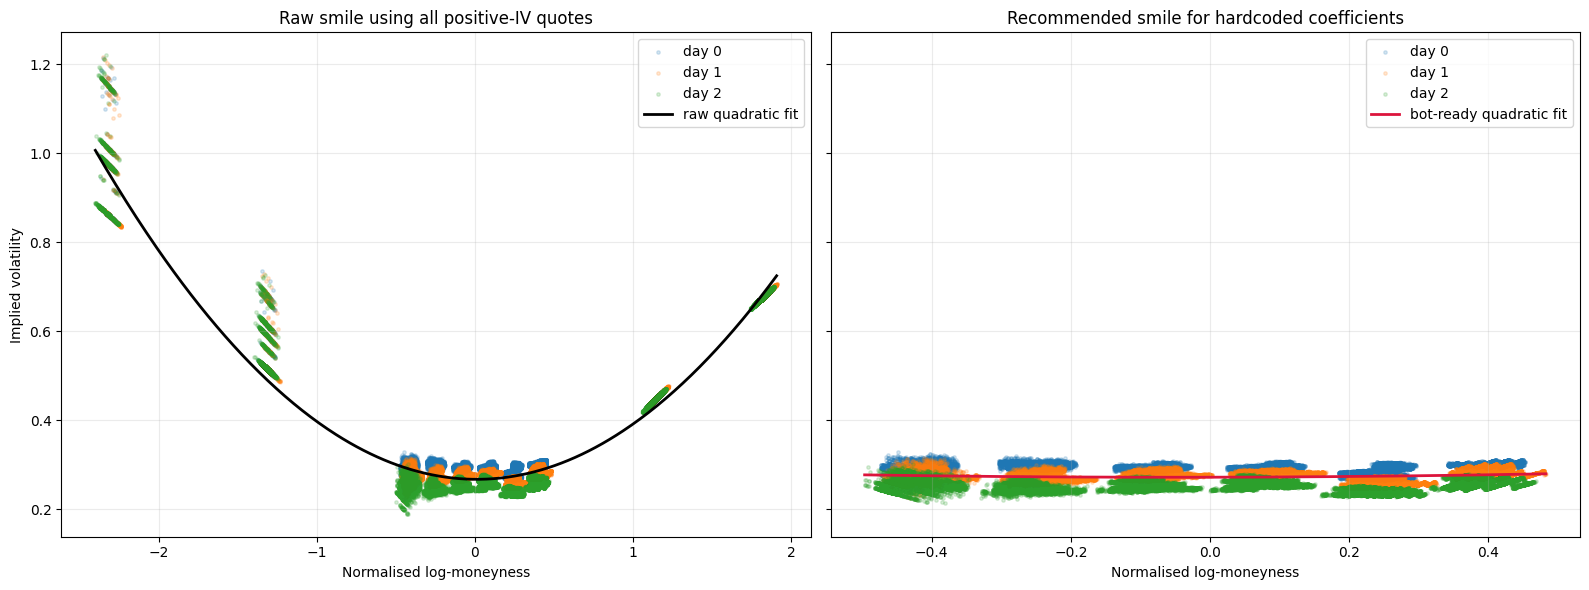

moneyness                implied_vol                extrinsic_value  \
              mean     std  count        mean     std  count            mean   
product                                                                        
VEV_5000   -0.4166  0.0252  29771      0.2756  0.0187  29771          4.9559   
VEV_5100   -0.2478  0.0254  30000      0.2729  0.0222  30000         16.7074   
VEV_5200   -0.0819  0.0254  30000      0.2756  0.0175  30000         45.4504   
VEV_5300    0.0809  0.0254  30000      0.2784  0.0152  30000         46.7599   
VEV_5400    0.2406  0.0254  30000      0.2612  0.0184  30000         15.9519   
VEV_5500    0.3973  0.0254  30000      0.2832  0.0171  30000          6.6414   

                         
             std  count  
product                  
VEV_5000  1.9028  29771  
VEV_5100  4.8425  30000  
VEV_5200  7.8466  30000  
VEV_5300  6.2281  30000  
VEV_5400  3.4292  30000  
VEV_5500  1.7388  30000

In [6]:
# Raw fit: every observation with a positive IV solution.
raw_fit = observations[(observations["implied_vol"] > 0) & (observations["C"] > 0)].copy()

# Recommended bot fit: keep the informative strikes and exclude degenerate quotes.
# Deep ITM quotes can sit on intrinsic value (IV ~= 0), while far OTM wings are often pinned
# to the minimum tick and can explode the inversion. The central strikes are much stabler.
recommended_fit = observations[
    observations["K"].between(5000, 5500)
    & (observations["implied_vol"] > 0)
    & (observations["extrinsic_value"] > 1.0)
].copy()

raw_coeffs = np.polyfit(raw_fit["moneyness"], raw_fit["implied_vol"], deg=2)
SMILE_COEFFS = np.polyfit(recommended_fit["moneyness"], recommended_fit["implied_vol"], deg=2)
a, b, c = SMILE_COEFFS


def fitted_iv(S: float, K: float, T: float = T, coeffs: np.ndarray = SMILE_COEFFS) -> float:
    m = math.log(K / S) / math.sqrt(T)
    return float(np.poly1d(coeffs)(m))


print(f"raw all-quoted coeffs : [{raw_coeffs[0]:.8f}, {raw_coeffs[1]:.8f}, {raw_coeffs[2]:.8f}]")
print(f"bot-ready coeffs      : [{a:.8f}, {b:.8f}, {c:.8f}]")
print()
print(f"SMILE_COEFFS = [{a:.8f}, {b:.8f}, {c:.8f}]")

x_raw = np.linspace(raw_fit["moneyness"].min(), raw_fit["moneyness"].max(), 400)
x_bot = np.linspace(recommended_fit["moneyness"].min(), recommended_fit["moneyness"].max(), 400)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for day, group in observations.groupby("day"):
    valid_group = group[(group["implied_vol"] > 0) & (group["C"] > 0)]
    axes[0].scatter(
        valid_group["moneyness"],
        valid_group["implied_vol"],
        s=6,
        alpha=0.18,
        label=f"day {day}",
    )

axes[0].plot(x_raw, np.poly1d(raw_coeffs)(x_raw), color="black", linewidth=2.0, label="raw quadratic fit")
axes[0].set_title("Raw smile using all positive-IV quotes")
axes[0].set_xlabel("Normalised log-moneyness")
axes[0].set_ylabel("Implied volatility")
axes[0].grid(alpha=0.25)
axes[0].legend()

for day, group in recommended_fit.groupby("day"):
    axes[1].scatter(
        group["moneyness"],
        group["implied_vol"],
        s=6,
        alpha=0.18,
        label=f"day {day}",
    )

axes[1].plot(x_bot, np.poly1d(SMILE_COEFFS)(x_bot), color="crimson", linewidth=2.0, label="bot-ready quadratic fit")
axes[1].set_title("Recommended smile for hardcoded coefficients")
axes[1].set_xlabel("Normalised log-moneyness")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

recommended_fit.groupby("product")[["moneyness", "implied_vol", "extrinsic_value"]].agg(["mean", "std", "count"]).round(4)